In [1]:
import pandas as pd
from scipy import stats
from sklearn.metrics import silhouette_score
import warnings
import numpy as np
from sklearn.decomposition import PCA
from umap import UMAP
from hdbscan import HDBSCAN
import numpy as np

import matplotlib.pyplot as plt

from utils.skeletonPATS import SkeletonPATS
from pats.utils import load_multiple_samples, get_speaker_intervals

import torch
from torch.utils.data import Dataset, DataLoader
from utils.skeletonPATS import SkeletonPATS
from pats.utils import load_multiple_samples, get_speaker_intervals, get_all_missing_intervals
import numpy as np
from typing import List, Union, Optional

warnings.filterwarnings('ignore')


/home/paolo/Projects/Posemi/dataset/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Rappresentazione in Coordinate Polari Relative

In questa sezione trasformiamo uno scheletro da **coordinate cartesiane assolute** $(x, y)$ a **coordinate polari relative** $(r, cos\theta, sin\theta)$.
Questo approccio è **invariante rispetto alla posizione globale e alla scala** della ripresa e si concentra sulla configurazione geometrica delle articolazioni.

---

## 1. Logica di Encoding (Cinematica Diretta)

A differenza di una conversione polare standard, questo metodo utilizza la **struttura gerarchica (albero) dello scheletro**.
Per ogni giuntura `j`, definiamo il suo **genitore** `p` e il suo **nonno** `gp`.

* **Distanza (r)**:
  Calcoliamo la norma L2 del vettore segmentale:
  $$
  r_j = \sqrt{(x_j - x_p)^2 + (y_j - y_p)^2}
  $$

* **Angolo Relativo (θ)**:
  Invece di usare l’orientamento globale, calcoliamo la deviazione angolare rispetto al segmento precedente.
  Se ($\phi_j$) è l’angolo assoluto del segmento ($p \to j$) e ($\phi_p$) è l’angolo del segmento ($gp \to p$), l’angolo relativo è:
  $$
  \theta_{\text{rel}} = \phi_j - \phi_p
  $$

* **Rappresentazione Trigonometrica**:
  Per evitare le discontinuità nel range ($-\pi, \pi$), memorizziamo l’angolo tramite le sue componenti:
  $$
  (\cos\theta_{\text{rel}}, \sin\theta_{\text{rel}})
  $$

---

## 2. Ricostruzione (Decoding)

La funzione di decoding ricostruisce lo scheletro **partendo dalla radice** (il Neck, joint 0) e procedendo ricorsivamente lungo le catene gerarchiche.

* **Orientamento globale del segmento**:
  $$
  \phi_j = \phi_p + \theta_{\text{rel}, j}
  $$

* **Coordinate cartesiane finali**:
  $$
  x_j = x_p + r_j \cdot \cos(\phi_j)
  $$
  $$
  y_j = y_p + r_j \cdot \sin(\phi_j)
  $$

---

## 3. Analisi della Precisione

La validità dell’algoritmo è confermata da un **errore di ricostruzione massimo** estremamente basso, nell’ordine di ($4.22 \times 10^{-7}$).

Questo valore è tipicamente dovuto a **errori di troncamento in virgola mobile** derivanti dalle funzioni trigonometriche e **non influisce sulla qualità dei dati** per analisi o training.



In [2]:
class SkeletonDataset(Dataset):
    def __init__(self, speakers :Union[List[str], str] ="fallon", split="train", clip:Optional[int]=None):
        """
        data: tensor (N, 52, 2) o numpy array equivalente
        """
        skeleton_poses = []
        self.speakers = [speakers] if isinstance(speakers, str) else speakers
        for speaker in self.speakers:
            intervals = get_speaker_intervals(speaker=speaker, split=split)
        
            clips = load_multiple_samples(
                speaker=speaker, 
                interval_ids=intervals[clip:clip+1] if clip is not None else intervals,
            )
            for clip in clips:
                pose = clip['pose']  # (N, 52, 2)
                pose[:,0] = [0.0, 0.0]
                skeleton_poses.append(pose)

        skeleton_poses = np.concatenate(skeleton_poses, axis=0)
        skeleton_poses = SkeletonPATS.normalize_skeleton(skeleton_poses)

        skeleton_poses = torch.tensor(skeleton_poses, dtype=torch.float32)
        self.data = skeleton_poses



    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]
        


In [3]:
def encode_kinematics(pose: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    parents = np.array(SkeletonPATS.parents())
    T, J, _ = pose.shape
    
    # Escludiamo il root (indice 0) dai dati polari
    polar = np.zeros((T, J - 1, 3))
    root_pos = pose[:, 0, :].copy() 

    for j in range(1, J): # Partiamo da 1
        p = parents[j]
        # Calcolo vettori e angoli (stessa logica precedente)
        vec_j = pose[:, j, :] - pose[:, p, :]
        dist = np.linalg.norm(vec_j, axis=-1)
        phi_j = np.arctan2(vec_j[:, 1], vec_j[:, 0])

        gp = parents[p]
        if gp == -1:
            theta_local = phi_j
        else:
            vec_p = pose[:, p, :] - pose[:, gp, :]
            phi_p = np.arctan2(vec_p[:, 1], vec_p[:, 0])
            theta_local = phi_j - phi_p

        # Riempiamo l'indice j-1 perché abbiamo rimosso il root
        polar[:, j-1, 0] = dist
        polar[:, j-1, 1] = np.cos(theta_local)
        polar[:, j-1, 2] = np.sin(theta_local)
        
    return polar, root_pos

def decode_kinematics(polar: np.ndarray, root_pos: Optional[np.ndarray]=None) -> np.ndarray:
    parents = np.array(SkeletonPATS.parents())
    T, J_minus_1, _ = polar.shape
    J = J_minus_1 + 1
    
    pose = np.zeros((T, J, 2))
    if root_pos is not None:
         pose[:, 0, :] = root_pos
    global_angles = np.zeros((T, J))

    for j in range(1, J): # Ricostruiamo partendo dal primo figlio del root
        p = parents[j]
        
        # Recuperiamo i dati dall'indice j-1
        dist = polar[:, j-1, 0]
        theta_local = np.arctan2(polar[:, j-1, 2], polar[:, j-1, 1])
        
        if parents[p] == -1:
            global_angles[:, j] = theta_local
        else:
            global_angles[:, j] = global_angles[:, p] + theta_local
            
        pose[:, j, 0] = pose[:, p, 0] + dist * np.cos(global_angles[:, j])
        pose[:, j, 1] = pose[:, p, 1] + dist * np.sin(global_angles[:, j])
        
    return pose

In [4]:
fallon = SkeletonDataset(speakers="fallon", split="dev", clip=67)
fallon.data.shape
polar, root_pos = encode_kinematics(fallon.data.numpy())
cartesian = decode_kinematics(polar, root_pos)
np.allclose(fallon.data.numpy(), cartesian, atol=1e-6)

True

In [5]:
max_error = np.max(np.abs(fallon.data.numpy() - cartesian))
print(f"Errore massimo: {max_error}")

Errore massimo: 4.2250280718469924e-07


In [6]:
polar.shape

(79, 51, 3)

In [7]:
import sys
np.set_printoptions(threshold=sys.maxsize)
print(polar[0])

[[ 0.49918428 -0.99988848  0.0149339 ]
 [ 0.73784053  0.37709066 -0.92617637]
 [ 0.65410912 -0.99369866 -0.11208455]
 [ 0.50145257  0.99627912 -0.0861855 ]
 [ 0.8493669   0.2144849   0.97672731]
 [ 0.57999432  0.97421968  0.22560149]
 [ 0.41128132 -0.56349915 -0.82611668]
 [ 0.13784881  0.9891541  -0.14688136]
 [ 0.15074933  0.34738961  0.93772089]
 [ 0.11128268  0.98950624  0.14449029]
 [ 0.23466966 -0.82151049  0.57019341]
 [ 0.10950761  0.77277803 -0.63467634]
 [ 0.07237787  0.78485525 -0.61967915]
 [ 0.06142927  0.98678958 -0.16200708]
 [ 0.16200693 -0.44143876  0.89729136]
 [ 0.22565973  0.1586491  -0.98733503]
 [ 0.46042994 -0.37790832  0.925843  ]
 [ 0.04557478 -0.8791905  -0.47647044]
 [ 0.50321895 -0.7977649   0.60296863]
 [ 0.16681795 -0.20677978 -0.97838753]
 [ 0.09591136  0.94868314 -0.3162283 ]
 [ 0.08875224  0.99963516 -0.0270093 ]
 [ 0.4272559  -0.83792973  0.54577821]
 [ 0.13696145 -0.19379288 -0.98104244]
 [ 0.12634365  0.84355205 -0.53704745]
 [ 0.06544832  0.9526031 

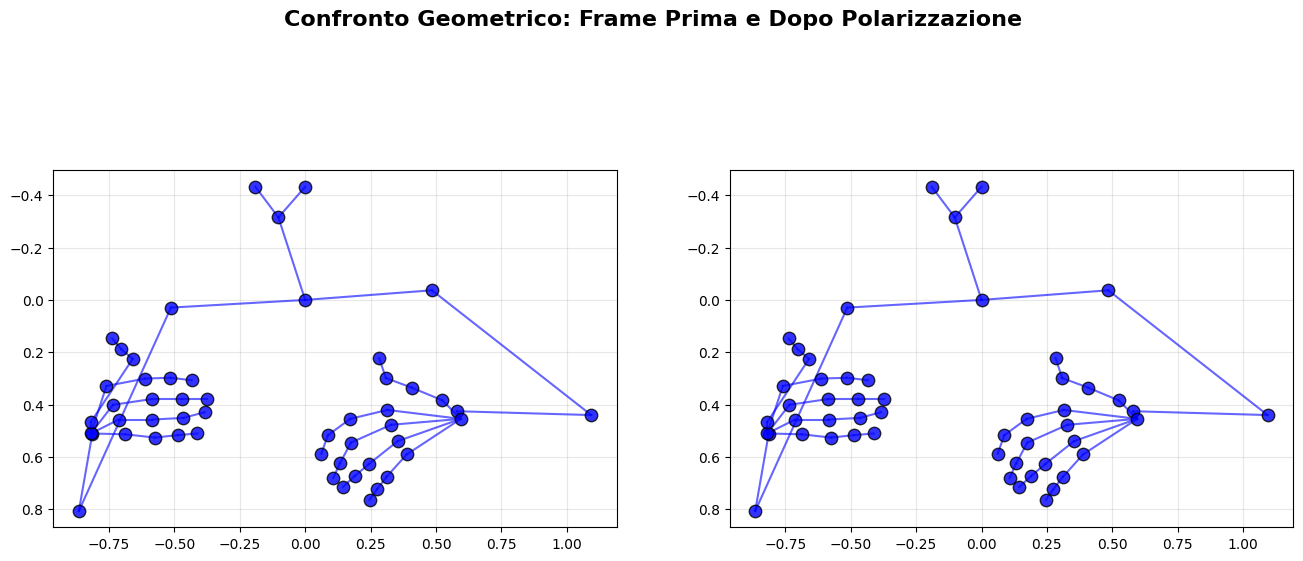

In [8]:
parents = SkeletonPATS.parents()
joint_names = SkeletonPATS.joint_names()

frame_num = 40

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Confronto Geometrico: Frame Prima e Dopo Polarizzazione', fontsize=16, fontweight='bold')
ax = axes[0]

frame_orig = fallon.data[frame_num].numpy()

for j, parent_idx in enumerate(parents):
    if parent_idx >= 0:
        ax.plot([frame_orig[j, 0], frame_orig[parent_idx, 0]],
               [frame_orig[j, 1], frame_orig[parent_idx, 1]],
               'b-', linewidth=1.5, alpha=0.6)

ax.scatter(frame_orig[:, 0], frame_orig[:, 1], c='blue', s=80, 
          edgecolors='black', linewidth=1, zorder=5, alpha=0.8)

ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()


ax = axes[1]

recon = cartesian[frame_num]

for j, parent_idx in enumerate(parents):
    if parent_idx >= 0:
        ax.plot([recon[j, 0], recon[parent_idx, 0]],
               [recon[j, 1], recon[parent_idx, 1]],
               'b-', linewidth=1.5, alpha=0.6)

ax.scatter(recon[:, 0], recon[:, 1], c='blue', s=80, 
          edgecolors='black', linewidth=1, zorder=5, alpha=0.8)

ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()


In [9]:
# Carica tutti gli intervalli disponibili
speaker = "fallon"
split = "dev"

intervals = get_speaker_intervals(speaker, split=split)
print(f"Numero totale di dataset disponibili: {len(intervals)}")

# Per test rapido, usa un subset. Per analisi completa, usa tutti
# N_DATASETS = 20  # subset per test veloce
N_DATASETS = len(intervals)  # tutti i dataset

print(f"Useremo {N_DATASETS} dataset per l'analisi")

Numero totale di dataset disponibili: 202
Useremo 202 dataset per l'analisi


In [10]:

def compute_clustering_metrics(poses: np.ndarray, min_cluster_size=20, min_samples=5, n_components=2):
    """
    Calcola metriche complete per valutare la qualità del clustering HDBSCAN
    
    Returns dict con:
    - persistence: somma delle persistenze dei cluster
    - noise_ratio: percentuale di punti classificati come rumore
    - avg_membership_prob: media delle probabilità di membership
    - n_clusters: numero di cluster trovati
    - silhouette: silhouette score sui punti non-rumore
    - cluster_sizes: lista delle dimensioni dei cluster
    """
    
    if len(poses) == 0:
        return None
    
    # Reshape e UMAP
    data = np.array(poses)
    transformer = UMAP(n_components=n_components)
    scaled = transformer.fit_transform(data.reshape(len(data), -1))
    
    # HDBSCAN con prediction_data=True per avere persistence e probabilities
    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples, 
        prediction_data=True
    )
    labels = clusterer.fit_predict(scaled)
    
    # Metriche base
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_mask = labels == -1
    noise_ratio = noise_mask.sum() / len(labels)
    
    # Persistence: somma delle persistenze dei cluster
    # Maggiore = cluster più stabili e ben separati
    persistence = 0.0
    if hasattr(clusterer, 'cluster_persistence_'):
        persistence = clusterer.cluster_persistence_.sum()
    
    # Probabilità di membership
    # Maggiore = clustering più sicuro/deciso
    avg_membership_prob = 0.0
    if hasattr(clusterer, 'probabilities_'):
        avg_membership_prob = clusterer.probabilities_.mean()
    
    # Silhouette solo sui punti non-rumore
    silhouette = -1.0
    if n_clusters > 1 and (~noise_mask).sum() > n_clusters:
        try:
            non_noise_points = scaled[~noise_mask]
            non_noise_labels = labels[~noise_mask]
            silhouette = silhouette_score(non_noise_points, non_noise_labels)
        except:
            silhouette = -1.0
    
    # Dimensioni dei cluster
    cluster_sizes = []
    for cluster_id in range(n_clusters):
        size = (labels == cluster_id).sum()
        cluster_sizes.append(size)
    
    return {
        'persistence': persistence,
        'noise_ratio': noise_ratio,
        'avg_membership_prob': avg_membership_prob,
        'n_clusters': n_clusters,
        'silhouette': silhouette,
        'cluster_sizes': cluster_sizes,
        'total_points': len(labels)
    }

In [11]:
from tqdm import tqdm

# Parametri HDBSCAN (stessi per entrambe le trasformazioni)
MIN_CLUSTER_SIZE = 30
MIN_SAMPLES = 25
N_COMPONENTS = 16

results = []

for idx in tqdm(range(N_DATASETS), desc="Analisi dataset"):
    try:
        clip = SkeletonDataset(speakers="fallon", split="dev", clip=idx)
        skeleton_poses = clip.data.numpy()
        
        # Salta dataset troppo piccoli
        if len(skeleton_poses) < MIN_CLUSTER_SIZE * 2:
            continue
        
        # Trasformazione polare
        polar_poses, _ = encode_kinematics(skeleton_poses)
        
        # Calcola metriche per cartesiano
        metrics_cartesian = compute_clustering_metrics(
            skeleton_poses, 
            min_cluster_size=MIN_CLUSTER_SIZE,
            min_samples=MIN_SAMPLES,
            n_components=N_COMPONENTS
        )
        
        # Calcola metriche per polare
        metrics_polar = compute_clustering_metrics(
            polar_poses,
            min_cluster_size=MIN_CLUSTER_SIZE,
            min_samples=MIN_SAMPLES,
            n_components=N_COMPONENTS
        )
        
        if metrics_cartesian is not None and metrics_polar is not None:
            results.append({
                'dataset_idx': idx,
                'n_frames': len(skeleton_poses),
                # Metriche cartesiano
                'cart_persistence': metrics_cartesian['persistence'],
                'cart_noise_ratio': metrics_cartesian['noise_ratio'],
                'cart_avg_prob': metrics_cartesian['avg_membership_prob'],
                'cart_n_clusters': metrics_cartesian['n_clusters'],
                'cart_silhouette': metrics_cartesian['silhouette'],
                # Metriche polare
                'polar_persistence': metrics_polar['persistence'],
                'polar_noise_ratio': metrics_polar['noise_ratio'],
                'polar_avg_prob': metrics_polar['avg_membership_prob'],
                'polar_n_clusters': metrics_polar['n_clusters'],
                'polar_silhouette': metrics_polar['silhouette'],
            })
    
    except Exception as e:
        print(f"Errore nel dataset {idx}: {e}")
        continue

# Converti in DataFrame
df_results = pd.DataFrame(results)
print(f"\nDataset analizzati con successo: {len(df_results)}")
print(f"\nPrime righe dei risultati:")
print(df_results.head())

Analisi dataset:   0%|          | 0/202 [00:00<?, ?it/s]

Analisi dataset:  45%|████▌     | 91/202 [05:21<05:46,  3.12s/it] 

Errore nel dataset 90: need at least one array to concatenate


Analisi dataset:  50%|█████     | 102/202 [06:01<04:56,  2.97s/it]

Errore nel dataset 101: need at least one array to concatenate


...

Errore nel dataset 115: need at least one array to concatenate


Analisi dataset:  95%|█████████▍| 191/202 [11:03<00:29,  2.68s/it]

Errore nel dataset 190: need at least one array to concatenate


Analisi dataset: 100%|██████████| 202/202 [11:47<00:00,  3.50s/it]

Errore nel dataset 201: need at least one array to concatenate

Dataset analizzati con successo: 197

Prime righe dei risultati:
   dataset_idx  n_frames  cart_persistence  cart_noise_ratio  cart_avg_prob  \
0            0       735          1.963305          0.000000       0.960074   
1            1       409          1.962613          0.000000       0.881508   
2            2       123          0.000000          1.000000       0.000000   
3            3       294          1.762377          0.010204       0.950396   
4            4       567          2.467992          0.044092       0.844693   

   cart_n_clusters  cart_silhouette  polar_persistence  polar_noise_ratio  \
0                4         0.693258           1.369164           0.000000   
1                5         0.674312           0.930361           0.000000   
2                0        -1.000000           0.709689           0.121951   
3                4         0.678263           0.866015           0.000000   
4          

In [12]:
# Calcola differenze per ogni metrica
# Per persistence, avg_prob, silhouette: valori più alti = meglio → Delta > 0 significa polare meglio
# Per noise_ratio: valori più bassi = meglio → Delta < 0 significa polare meglio

df_results['delta_persistence'] = df_results['polar_persistence'] - df_results['cart_persistence']
df_results['delta_noise_ratio'] = df_results['polar_noise_ratio'] - df_results['cart_noise_ratio']
df_results['delta_avg_prob'] = df_results['polar_avg_prob'] - df_results['cart_avg_prob']
df_results['delta_n_clusters'] = df_results['polar_n_clusters'] - df_results['cart_n_clusters']
df_results['delta_silhouette'] = df_results['polar_silhouette'] - df_results['cart_silhouette']

print("Statistiche descrittive delle differenze:\n")
delta_cols = [col for col in df_results.columns if col.startswith('delta_')]
print(df_results[delta_cols].describe())

Statistiche descrittive delle differenze:

       delta_persistence  delta_noise_ratio  delta_avg_prob  delta_n_clusters  \
count         197.000000         197.000000      197.000000        197.000000   
mean           -0.357321           0.069083       -0.036142         -0.583756   
std             0.726420           0.367569        0.346236          1.358773   
min            -2.602477          -1.000000       -0.996989         -8.000000   
25%            -0.917887           0.000000       -0.064150         -1.000000   
50%            -0.260411           0.000000        0.000000          0.000000   
75%             0.005556           0.092025        0.087618          0.000000   
max             1.787636           1.000000        0.963874          3.000000   

       delta_silhouette  
count        197.000000  
mean          -0.111614  
std            0.692651  
min           -1.937276  
25%           -0.110086  
50%            0.000000  
75%            0.059814  
max            1.96

In [13]:
def perform_paired_tests(cart_values, polar_values, metric_name, higher_is_better=True):
    """
    Esegue test statistici appaiati e stampa i risultati
    """
    # Calcola differenze
    deltas = polar_values - cart_values
    
    # Statistiche descrittive
    mean_cart = cart_values.mean()
    std_cart = cart_values.std()
    mean_polar = polar_values.mean()
    std_polar = polar_values.std()
    mean_delta = deltas.mean()
    std_delta = deltas.std()
    median_delta = deltas.median()
    
    # Test di normalità delle differenze (Shapiro-Wilk)
    _, p_shapiro = stats.shapiro(deltas)
    is_normal = p_shapiro > 0.05
    
    # Paired t-test
    t_stat, p_ttest = stats.ttest_rel(polar_values, cart_values)
    
    # Wilcoxon signed-rank test
    w_stat, p_wilcoxon = stats.wilcoxon(polar_values, cart_values, alternative='two-sided')
    
    # Cohen's d (effect size)
    cohens_d = mean_delta / std_delta if std_delta > 0 else 0
    
    # Percentuale di dataset dove polare è meglio
    if higher_is_better:
        pct_polar_better = (deltas > 0).sum() / len(deltas) * 100
    else:
        pct_polar_better = (deltas < 0).sum() / len(deltas) * 100
    
    # Stampa risultati
    print(f"\n{'='*70}")
    print(f"📊 METRICA: {metric_name}")
    print(f"{'='*70}")
    print(f"\n📈 Statistiche Descrittive:")
    print(f"   Cartesiano:  μ={mean_cart:.4f}, σ={std_cart:.4f}")
    print(f"   Polare:      μ={mean_polar:.4f}, σ={std_polar:.4f}")
    print(f"   Differenza:  μ={mean_delta:.4f}, σ={std_delta:.4f}, mediana={median_delta:.4f}")
    print(f"   {'Polare meglio' if higher_is_better else 'Polare meno rumore'} in {pct_polar_better:.1f}% dei dataset")
    
    print(f"\n🧪 Test Statistici:")
    print(f"   Normalità (Shapiro-Wilk): p={p_shapiro:.4f} → {'Normale' if is_normal else 'Non normale'}")
    print(f"   Paired t-test:     t={t_stat:.4f}, p={p_ttest:.6f} → {'✅ SIGNIFICATIVO' if p_ttest < 0.05 else '❌ Non significativo'}")
    print(f"   Wilcoxon test:     W={w_stat:.0f}, p={p_wilcoxon:.6f} → {'✅ SIGNIFICATIVO' if p_wilcoxon < 0.05 else '❌ Non significativo'}")
    print(f"   Effect size (Cohen's d): {cohens_d:.4f}")
    
    if abs(cohens_d) < 0.2:
        effect_interpretation = "trascurabile"
    elif abs(cohens_d) < 0.5:
        effect_interpretation = "piccolo"
    elif abs(cohens_d) < 0.8:
        effect_interpretation = "medio"
    else:
        effect_interpretation = "grande"
    
    print(f"   Interpretazione effect size: {effect_interpretation}")
    
    # Conclusione
    print(f"\n💡 Conclusione:")
    is_significant = p_wilcoxon < 0.05  # Usiamo Wilcoxon come test più robusto
    
    if is_significant:
        direction = "POLARE" if (mean_delta > 0 and higher_is_better) or (mean_delta < 0 and not higher_is_better) else "CARTESIANO"
        print(f"   ⭐ La trasformazione {direction} è SIGNIFICATIVAMENTE MIGLIORE (p<0.05)")
        print(f"      con effect size {effect_interpretation}")
    else:
        print(f"   ⚠️  NON c'è differenza statisticamente significativa tra le trasformazioni")
    
    return {
        'metric': metric_name,
        'mean_delta': mean_delta,
        'median_delta': median_delta,
        'std_delta': std_delta,
        'p_ttest': p_ttest,
        'p_wilcoxon': p_wilcoxon,
        'cohens_d': cohens_d,
        'pct_polar_better': pct_polar_better,
        'is_significant': is_significant
    }

# Esegui test per tutte le metriche principali
test_results = []

test_results.append(perform_paired_tests(
    df_results['cart_persistence'], 
    df_results['polar_persistence'],
    'PERSISTENCE (stabilità cluster)',
    higher_is_better=True
))

test_results.append(perform_paired_tests(
    df_results['cart_noise_ratio'], 
    df_results['polar_noise_ratio'],
    'NOISE RATIO (% rumore)',
    higher_is_better=False  # meno rumore = meglio
))

test_results.append(perform_paired_tests(
    df_results['cart_avg_prob'], 
    df_results['polar_avg_prob'],
    'AVG MEMBERSHIP PROBABILITY',
    higher_is_better=True
))

# Silhouette solo se ci sono valori validi
valid_silhouette = (df_results['cart_silhouette'] > -1) & (df_results['polar_silhouette'] > -1)
if valid_silhouette.sum() > 10:
    test_results.append(perform_paired_tests(
        df_results.loc[valid_silhouette, 'cart_silhouette'], 
        df_results.loc[valid_silhouette, 'polar_silhouette'],
        'SILHOUETTE SCORE',
        higher_is_better=True
    ))


📊 METRICA: PERSISTENCE (stabilità cluster)

📈 Statistiche Descrittive:
   Cartesiano:  μ=1.1934, σ=0.8682
   Polare:      μ=0.8361, σ=0.7158
   Differenza:  μ=-0.3573, σ=0.7264, mediana=-0.2604
   Polare meglio in 25.4% dei dataset

🧪 Test Statistici:
   Normalità (Shapiro-Wilk): p=0.0136 → Non normale
   Paired t-test:     t=-6.9041, p=0.000000 → ✅ SIGNIFICATIVO
   Wilcoxon test:     W=3034, p=0.000000 → ✅ SIGNIFICATIVO
   Effect size (Cohen's d): -0.4919
   Interpretazione effect size: piccolo

💡 Conclusione:
   ⭐ La trasformazione CARTESIANO è SIGNIFICATIVAMENTE MIGLIORE (p<0.05)
      con effect size piccolo

📊 METRICA: NOISE RATIO (% rumore)

📈 Statistiche Descrittive:
   Cartesiano:  μ=0.2359, σ=0.3882
   Polare:      μ=0.3050, σ=0.4168
   Differenza:  μ=0.0691, σ=0.3676, mediana=0.0000
   Polare meno rumore in 22.3% dei dataset

🧪 Test Statistici:
   Normalità (Shapiro-Wilk): p=0.0000 → Non normale
   Paired t-test:     t=2.6380, p=0.009011 → ✅ SIGNIFICATIVO
   Wilcoxon test:  